# TSFresh-Features aus rohem, PCA- und DyCA-gefiltertem TEP-Signal

Umsetzung des zweiten TODO-Punkts aus `LazyClassifier_PCA_DyCA.ipynb`: statt der
**Eigenwerte** werden hier **TSFresh-Features** direkt aus dem Zeitsignal gewonnen —
einmal aus dem ungefilterten Signal, einmal aus dem PCA-projizierten und einmal aus
dem DyCA-projizierten. Anschließend Feature Selection auf die besten `top_k` Features
und LazyClassifier.

## Die 11 Konfigurationen

| Konfiguration | Kanäle | Projektion |
|---|---|---|
| `raw` | 52 | keine — die 52 Prozessvariablen direkt |
| `pca_4 … pca_12` | 4, 6, 8, 10, 12 | PCA pro Run, Scores der ersten *n* Hauptkomponenten |
| `dyca_m2_n4 … dyca_m6_n12` | 4, 6, 8, 10, 12 | DyCA pro Run, `amplitudes` (n, time) |

Zusammen 52 + 40 + 40 = **132 Kanäle pro Run**. Die DyCA-Paare sind n = 2m; das ist
exakt der Grenzfall der Bedingung `m >= n - m`, die das `dyca`-Paket erzwingt.

## Vorgehen (dreistufig)

**Phase A — Extraktion + Selektion auf TRAIN.** Je Konfiguration werden alle
TSFresh-Features auf allen Trainingsruns berechnet (`EfficientFCParameters`,
~780 Features je Kanal), daraus per Relevanztabelle die besten `top_k` ausgewählt.
Danach wird die volle Matrix sofort verworfen und nur `top_k` behalten.

**Phase B — Testset.** `tsfresh.feature_extraction.settings.from_columns()` übersetzt
die ausgewählten Featurenamen zurück in `kind_to_fc_parameters`. Auf dem Testset
werden deshalb **nur diese Features** berechnet — um Größenordnungen billiger als die
volle Extraktion. Die Selektion sieht das Testset nie.

**Phase C — LazyClassifier** je Konfiguration, dann Vergleich über alle 11.

## Laufzeit und Speicher — bitte vor dem Start lesen

Werte aus einem vollständigen Durchlauf auf dieser Maschine (8 Kerne,
`EfficientFCParameters`, `n_jobs=8`, alle 500 Runs je Fault): **30,2 Zeitreihen/s**.
Phase A dauerte **14,1 h** (davon allein 5,4 h für die 52 Rohkanäle), Phase B
1,4 h, Phase C 22 min — zusammen rund **16 h**.

Die Roh-Konfiguration erzeugt **40 404 Features pro Run** — als `float32` sind das
1,7 GB für die Trainingsmatrix. Deshalb: Feature-Matrizen als `float32`,
Konfigurationen strikt nacheinander, Relevanztests in Spaltenblöcken. Das
*projizierte Signal* geht dagegen als `float64` in TSFresh (Begründung im
Abschnitt „Projektionen").

**Der Cache macht den Lauf unterbrechbar.** Jeder Chunk landet als Pickle in
`cache_dir`; ein Neustart überspringt alles bereits Berechnete. Abbrechen ist also
gefahrlos.

> **`smoke_test` steht in der Konfigurationszelle.** Mit `True` läuft die komplette
> Pipeline in wenigen Minuten auf wenigen Runs durch — zum Prüfen, dass alles
> funktioniert. Für den echten Lauf auf `False` (am besten in tmux/über Nacht).
> Die Caches beider Modi liegen in getrennten Verzeichnissen.

## Code-Struktur

Der gesamte Maschinenraum liegt im Paket [`tep/`](tep) und wird von allen
TEP-Notebooks geteilt. Dieses Notebook enthält nur noch, was es von
seinen Geschwistern unterscheidet: die Konfiguration, die Liste der
Projektions-Specs und die Aufrufe.

| Modul | Inhalt |
|---|---|
| `tep/core.py` | Spaltennamen, Splits, Cutoffs, Vorverarbeitung, lineare Algebra — geteilt mit `tep.eigen` |
| `tep/plotting.py` | Confusion-Matrix-Darstellung, ebenfalls geteilt |
| `tep/tsfresh/config.py` | `PipelineConfig` — alle Stellschrauben |
| `tep/tsfresh/projections.py` | Registry der Verfahren: `raw`, `pca`, `dyca`, `dpca`, `cva`, `ica`, `dycvda` |
| `tep/tsfresh/features.py` | Chunk-Cache-Extraktion, Feature-Ranking |
| `tep/tsfresh/pipeline.py` | Phase A / B / C |
| `tep/tsfresh/reporting.py` | Vergleichstabellen und Balkenplot |
| `tep/tsfresh/confusion.py` | Confusion-Matrizen und ihre drei Plots |

Eine Projektion ist ein `Projector` mit drei Angaben: wie sie heisst (der
Name ist zugleich Cache-Praefix), wie ihre Kanaele heissen und wie sie
rechnet. Ein eigenes Verfahren kommt über `tep.tsfresh.register(...)`
dazu, ohne dass hier etwas angefasst werden muss.

> Die Rechnungen sind zeilengetreu aus der früheren Notebook-Fassung
> uebernommen — Projektionen und Cache-Praefixe wurden vor dem Umbau
> ueber alle Konfigurationen und beide Skalierungsmodi als bitidentisch
> nachgewiesen. Der vorhandene Chunk-Cache bleibt damit gueltig.


In [1]:
# ============================================================
# Imports - der gemeinsame Unterbau steckt im Paket tep
# ============================================================
# Wird tep/**.py bearbeitet, muss der Kernel neu gestartet werden;
# alternativ die beiden autoreload-Zeilen aktivieren.
# %load_ext autoreload
# %autoreload 2

# numpy/pandas werden hier nicht gebraucht, stehen aber fuer eigene
# Auswertungen am Ende des Notebooks bereit.
import numpy as np
import pandas as pd

from tep.tsfresh import (Pipeline, PipelineConfig, plot_confusion_detail,
                         plot_recall, versions)

print(versions())

tsfresh 0.21.2 | pandas 3.0.3 | numpy 2.4.6 | sklearn 1.9.0 | Kerne: 8


In [2]:
# ============================================================
# Konfiguration - die EINZIGE Stelle, an der geschraubt wird
# ============================================================
# Alle nicht gesetzten Felder stehen auf den Defaults aus
# tep/tsfresh/config.py (top_k=100, fc_mode='efficient',
# chunk_runs=250, run_length=480, lc_cv_folds=5, ...).
# smoke_test=True gibt einen winzigen Probelauf in einem
# eigenen Cache-Ordner - ueberschreibt also nichts.

PCA_NS = [4, 6, 8, 10, 12]                            # PCA-Komponenten
DYCA_MN = [(2, 4), (3, 6), (4, 8), (5, 10), (6, 12)]  # DyCA (m, n), n = 2m

CFG = PipelineConfig(
    configs=([("raw",)]
             + [("pca", n) for n in PCA_NS]
             + [("dyca", m, n) for (m, n) in DYCA_MN]),
    label="PCA/DyCA",
    # Eigene Ergebnisdateien je Notebook-Familie: der Cache-Ordner ist
    # geteilt, die Schwester-Notebooks sollen sich nicht ueberschreiben.
    summary_csv="tsfresh_summary.csv",
    cm_pred_csv="tsfresh_cm_predictions.csv",
    scaling_mode="global_mean",
    data_dir="data",            # Ordner mit den vier TEP-CSVs
)

## Rohdaten laden

Die Runs werden **einmal** in ein Dictionary `{(faultNumber, simulationRun): Array}`
gelesen und danach für alle 11 Konfigurationen wiederverwendet — die TEP-CSVs
(besonders `TEP_Faulty_Testing.csv` mit 3,4 GB) sollen nur ein Mal durch den Parser.

Speicher: mit `float32` und nur den benötigten Spalten sind das je ~1,05 GB für
Train und Test (beide Splits werden auf `run_length` gekürzt, siehe unten). Train
und Test werden **nie gleichzeitig** gehalten — Phase A braucht nur Train,
Phase B nur Test.

Sortiert wird pro Run (nicht global), weil ein globales `sort_values` über 10 Mio.
Zeilen eine komplette Kopie anlegen würde. DyCA braucht die zeitliche Ordnung für
die Ableitung, PCA nicht — sortiert wird trotzdem für beide, damit die Kanäle
identisch entstehen.

### `uniform_length` — bewusste Abweichung von den Eigenwert-Notebooks

Dort behält Fault 0 alle 500 Samples, während bei Fault 1–20 der Pre-Fault-Bereich
verworfen wird (480 Samples). Für die Eigenwerte ist das unkritisch — die erklärten
Varianzanteile sind praktisch längenunabhängig.

**Für TSFresh wäre es ein Kunstfehler.** `length` ist ein Feature (schon in
`MinimalFCParameters`), und `abs_energy`, `sum_values` oder `count_above_mean`
skalieren mit der Reihenlänge. Fault 0 wäre damit an der Länge allein perfekt
erkennbar — ein Artefakt der Vorverarbeitung, kein Prozesssignal. Der Klassifizierer
würde darauf hereinfallen und die Ergebnisse wären wertlos.

`uniform_length=True` wendet den Cutoff deshalb **auch auf Fault 0** an.

### `run_length` — gleiche Länge auch zwischen Train und Test

Damit wären die Runs *innerhalb* eines Splits gleich lang, zwischen den Splits aber
immer noch nicht: Training hat nach dem Cutoff 480 Samples, Test 800. Genau dieselben
längenabhängigen Features (`abs_energy`, `sum_values`, `absolute_sum_of_changes`,
`count_above_mean`, `number_peaks`, …) hätten dann in Train und Test **systematisch
verschiedene Größenordnungen** — ein Modell, das auf 480er-Werten trainiert wurde,
bekäme im Test rund das 1,7-Fache zu sehen. Das beschädigt jede Konfiguration
gleichermaßen und macht die Testbewertung wertlos.

`run_length = 480` kürzt deshalb **jeden** Run auf die ersten 480 Post-Fault-Samples.
Das entspricht in beiden Splits demselben physikalischen Fenster: 480 × 3 min = 24 h
nach Fehlereintritt. Vom Testset werden dadurch 320 Samples je Run verworfen — der
Preis dafür, dass Train- und Test-Features überhaupt dieselbe Bedeutung haben.

> Derselbe Effekt ist übrigens ein plausibler Mitgrund dafür, dass DyCA im
> Eigenwert-Notebook von 0,81 (CV auf Train) auf 0,39 (Test) einbricht — dort werden
> die Eigenwerte aus 480- bzw. 800-Sample-Fenstern berechnet.

## Projektionen: roh, PCA, DyCA

Alle drei Varianten bekommen **dieselbe Vorverarbeitung**, gesteuert über
`scaling_mode`. Damit unterscheidet sich zwischen den Konfigurationen wirklich nur
die Projektion.

### `scaling_mode` — hier hängt mehr dran, als es aussieht

`"global_mean"` ist die Zeile, die aktuell auch in den Eigenwert-Notebooks
steht:
`X_scaled = X - X.mean()`. Das zieht einen **skalaren** Gesamtmittelwert über alle
52 Variablen und alle Zeitpunkte ab — die *spaltenweisen* Mittelwerte bleiben also
vollständig erhalten. Da die TEP-Variablen völlig verschiedene Größenordnungen haben
(`xmeas_2` ≈ 3663, `xmeas_1` ≈ 0,25), bleibt in jeder Spalte ein großer Gleichanteil
stehen.

Für **PCA** ist das folgenlos — `sklearn.PCA` zentriert intern ohnehin spaltenweise.
Für **DyCA** nicht: dessen Korrelationsmatrix `C0 = XᵀX/T` ist *unzentriert*, der
Gleichanteil dominiert sie also. Gemessen an einzelnen Runs (Faults 0, 1, 6, 13):

| Vorverarbeitung | std/\|mean\| der DyCA-Amplituden |
|---|---|
| `"global_mean"` | **1e-5 … 1e-3** |
| `"scaler"` | **0,3 … 28** |

Mit `"global_mean"` sind die DyCA-Kanäle, die in TSFresh gehen, numerisch also fast
reine Konstanten — die eigentliche Dynamik liegt drei bis fünf Größenordnungen
darunter. Das ist ein plausibler Hauptgrund dafür, dass DyCA sowohl hier als auch im
Eigenwert-Notebook schlecht abschneidet, und es ist genau das, was der dortige
TODO-Kommentar bereits vermutet.

`"scaler"` fittet einen `StandardScaler` auf `TEP_FaultFree_Training` (Normalbetrieb),
exakt wie in den anderen Notebooks. **Aktuell ist `"global_mean"` eingestellt** —
im Gleichklang mit den Eigenwert-Notebooks, die ebenfalls wieder auf
`X - X.mean()` stehen. Der Cache-Ordner bekommt den Modus automatisch in
den Namen (`tsfresh_cache` für `global_mean`, `tsfresh_cache_scaler` für
`"scaler"`); beide Ergebnissätze bleiben also nebeneinander erhalten.

**PCA und DyCA werden beide pro Run gefittet.** DyCA kann gar nicht anders (es sucht
den Unterraum der Dynamik *dieses* Laufs), und für PCA hält das den Vergleich
symmetrisch — sonst würde man Methode und Fit-Modus vermischen.

**Vorzeichenkonvention.** Pro Run gefittete Achsen sind nur bis aufs Vorzeichen
bestimmt: PCA-Komponenten dürfen beliebig gespiegelt werden, DyCA-Amplituden ebenso
(SVD). Für die Eigenwerte in den bestehenden Notebooks war das egal — sie sind
vorzeicheninvariant. TSFresh-Features sind es **nicht**: `mean`, `skewness` oder die
Steigung von `linear_trend` kippen mit. Ohne Konvention wäre ein Teil der Features
reines Rauschen. `fix_signs=True` dreht deshalb jeden Kanal so, dass sein betragsmäßig
größter Wert positiv ist — deterministisch und für PCA wie DyCA identisch.

Bleibt die Einschränkung, dass pro Run gefittete Achsen in verschiedenen Runs
verschiedene physikalische Richtungen sind. Formstatistiken (Autokorrelation,
Spektrum, Entropie) bleiben vergleichbar; lageabhängige Features sind mit Vorsicht
zu lesen. Das ist der Preis der Symmetrie zu DyCA.

In [3]:
# ============================================================
# Pipeline anlegen
# ============================================================
# Prueft die Specs (Rangbedingungen der Verfahren, doppelte Namen) und
# fittet bei scaling_mode="scaler" den StandardScaler auf dem
# Normalbetrieb. Danach steht der Umfang des Laufs im Klartext da.
pipe = Pipeline(CFG)
pipe.describe()

smoke_test=False | fc_mode=efficient (73 Calculator) | top_k=100 | scaling_mode=global_mean
Runs je Fault: alle | Cache: tsfresh_cache/ (geteilt mit den Schwester-Notebooks)

11 Konfigurationen:
  raw                     52 Kanaele -> ~3796 Features/Run (Groessenordnung)
  pca_4                    4 Kanaele -> ~292 Features/Run (Groessenordnung)
  pca_6                    6 Kanaele -> ~438 Features/Run (Groessenordnung)
  pca_8                    8 Kanaele -> ~584 Features/Run (Groessenordnung)
  pca_10                  10 Kanaele -> ~730 Features/Run (Groessenordnung)
  pca_12                  12 Kanaele -> ~876 Features/Run (Groessenordnung)
  dyca_m2_n4               4 Kanaele -> ~292 Features/Run (Groessenordnung)
  dyca_m3_n6               6 Kanaele -> ~438 Features/Run (Groessenordnung)
  dyca_m4_n8               8 Kanaele -> ~584 Features/Run (Groessenordnung)
  dyca_m5_n10             10 Kanaele -> ~730 Features/Run (Groessenordnung)
  dyca_m6_n12             12 Kanaele -> ~876

## Phase A — Extraktion und Selektion auf dem Trainingssatz

Je Konfiguration:

1. **Extrahieren** in Chunks à `chunk_runs` Runs. Jeder Chunk wird als `float32`-Pickle
   gecacht — ein Abbruch kostet höchstens den angefangenen Chunk.
2. **Selektieren:** Relevanztabelle in Spaltenblöcken (`block_cols`), damit die
   Roh-Konfiguration mit 40 404 Features nicht den Speicher sprengt.
3. **Reduzieren** auf `top_k` und die volle Matrix sofort freigeben.

**Zur Rangfolge.** Bei 10 500 Trainingsruns unterlaufen die p-Werte der
Signifikanztests reihenweise auf exakt 0.0 — nach p-Wert allein wären hunderte
Features gleichauf und die Auswahl der „besten 100" wäre willkürlich. Deshalb:
tsfresh liefert mit `n_significant` die Zahl der Klassen, die ein Feature signifikant
trennt (das ist bei `n_significant=1` genau das `relevant`-Kriterium), und innerhalb
gleicher `n_significant` wird nach dem **ANOVA-F-Wert** sortiert — eine stetige
Effektstärke, die nicht unterläuft.

Die Blockweise verschiebt die Benjamini-Hochberg-Korrektur minimal (sie sieht je Block
nur dessen p-Werte). Für eine *Rangfolge* ist das ohne Belang; darauf beruht die
Auswahl hier auch.

In [4]:
# ============================================================
# PHASE A: Train extrahieren -> selektieren -> auf top_k reduzieren
# ============================================================
# Laeuft aus dem Chunk-Cache weiter, wenn schon Chunks vorhanden sind.
# Ergebnis liegt danach in pipe.train_top und pipe.top_names.
pipe.run_phase_a()

Lade Trainingsruns ...
  lese TEP_FaultFree_Training.csv ...
  lese TEP_Faulty_Training.csv ...
  train: 10500 Runs, Laenge(n) [480], 1.05 GB


raw                  [train/full]:   0%|          | 0/42 [00:00<?, ?it/s]

[raw] Auswahl aus Cache, 10500 Runs
[raw] fertig: (10500, 100) in 0.0 min


pca_4                [train/full]:   0%|          | 0/42 [00:00<?, ?it/s]

[pca_4] Auswahl aus Cache, 10500 Runs
[pca_4] fertig: (10500, 100) in 0.0 min


...

[dyca_m4_n8] Auswahl aus Cache, 10013 Runs
[dyca_m4_n8] fertig: (10013, 100) in 0.0 min


dyca_m5_n10          [train/full]:   0%|          | 0/42 [00:00<?, ?it/s]

[dyca_m5_n10] Auswahl aus Cache, 10013 Runs
[dyca_m5_n10] fertig: (10013, 100) in 0.0 min


dyca_m6_n12          [train/full]:   0%|          | 0/42 [00:00<?, ?it/s]

[dyca_m6_n12] Auswahl aus Cache, 10013 Runs
[dyca_m6_n12] fertig: (10013, 100) in 0.0 min

Phase A komplett in 0.8 min


## Phase B — dieselben Features auf dem Testset

`from_columns()` übersetzt die ausgewählten Featurenamen zurück in ein
`kind_to_fc_parameters`-Dictionary. `extract_features` berechnet damit **nur** diese
Features — und auch nur auf den Kanälen, die in der Auswahl überhaupt vorkommen.
Deshalb ist Phase B um Größenordnungen billiger als Phase A (gemessen 1,4 h
gegenüber 14,1 h). Die Runs sind in beiden Splits gleich lang, weil `run_length`
auch die Testruns auf 480 Post-Fault-Samples kürzt.

Die Selektion hat ausschließlich Trainingsdaten gesehen — das Testset bleibt eine
unverzerrte Generalisierungsschätzung.

In [5]:
# ============================================================
# PHASE B: Testset - nur die in Phase A ausgewaehlten Features
# ============================================================
# Ergebnis liegt danach in pipe.test_top.
pipe.run_phase_b()

Lade Testruns ...
  lese TEP_FaultFree_Testing.csv ...
  lese TEP_Faulty_Testing.csv ...
  test: 10500 Runs, Laenge(n) [480], 1.05 GB


raw                  [test/top100]:   0%|          | 0/42 [00:00<?, ?it/s]

[raw] Test fertig: (10500, 100) in 0.0 min


pca_4                [test/top100]:   0%|          | 0/42 [00:00<?, ?it/s]

[pca_4] Test fertig: (10500, 100) in 0.0 min


...

[dyca_m4_n8] Test fertig: (9996, 100) in 0.0 min


dyca_m5_n10          [test/top100]:   0%|          | 0/42 [00:00<?, ?it/s]

[dyca_m5_n10] Test fertig: (9996, 100) in 0.0 min


dyca_m6_n12          [test/top100]:   0%|          | 0/42 [00:00<?, ?it/s]

[dyca_m6_n12] Test fertig: (9996, 100) in 0.0 min


## Phase C — LazyClassifier je Konfiguration

Alle 11 Konfigurationen laufen mit demselben Klassifizierer-Satz. Zwei Dinge sind
bewusst so gesetzt:

**Identische Run-Menge.** DyCA scheitert sporadisch und verliert Runs — und zwar
genau die Runs, an denen es numerisch scheitert. Würde man jede Konfiguration auf
ihrer eigenen Restmenge bewerten, bekämen die DyCA-Setups ein anderes (potenziell
leichteres) Testset als `raw` und die PCA-Setups. `restrict_to_common_runs=True`
schneidet deshalb alle auf die Runs zu, die in **allen** Konfigurationen vorhanden
sind.

**Macro-F1 als Kernzahl.** Balanced Accuracy ist der Macro-Recall und sieht Precision
nicht — sie belohnt Modelle, die eine Klasse als Sammelbecken missbrauchen. Macro-F1
bestraft das. Beides wird berichtet; lazypredicts eigene `F1 Score`-Spalte ist die
*gewichtete* Variante und deshalb hier nicht die Vergleichszahl.

**Modellauswahl über 5-fache CV — RandomForest bleibt der Hauptvergleich.**
Phase C läuft mit `lc_cv_folds = 5`: lazypredict kreuzvalidiert jedes Modell
zusätzlich auf den **Trainingsdaten** und liefert die Spalten `… CV Mean/Std`.
Die Auswahl „bestes Modell je Konfiguration" läuft darüber
(`BalancedAccCVMean`) und sieht das Testset nicht; berichtet werden weiterhin
die einmaligen Testwerte. Das alte Test-Maximum wird zum Vergleich mit
ausgegeben — es ist durch den Winner's Curse leicht optimistisch, und der
Abstand zwischen beiden zeigt, wie groß dieser Effekt hier ist.

Zwei Einschränkungen der CV:

- lazypredicts `F1 Score CV Mean` ist die **gewichtete** Variante; ein
  Macro-F1 aus der CV gibt es nicht. Selektionsmetrik ist deshalb
  `Balanced Accuracy CV Mean` — dieselbe Wahl wie `SELECT_METRIC` im
  Eigenwert-Notebook.
- Modelle **ohne `predict_proba`** (LinearSVC, Ridge, SGD, …) bekommen **keine**
  CV-Werte: lazypredict rechnet alle CV-Scorer gebündelt mit
  `error_score="raise"`, der ROC-AUC-Scorer braucht aber Wahrscheinlichkeiten —
  scheitert er, werden alle CV-Spalten dieses Modells geleert. Sie fallen damit
  aus der CV-Auswahl heraus (im Test-Maximum sind sie weiter dabei).

Der **RandomForest-Block** bleibt der belastbare Konfigurationsvergleich:
festes Modell, gar keine Auswahl.

> Kosten: die CV fittet jedes Modell fünfmal zusätzlich (Folds parallel,
> `n_jobs=-1`) — Phase C dauert grob das 2- bis 4-Fache. Die teuren Phasen A
> und B sind nicht betroffen und bleiben gecacht.

In [6]:
# ============================================================
# PHASE C: LazyClassifier je Konfiguration
# ============================================================
# Schreibt die summary-CSV in den Cache-Ordner und legt sie zusaetzlich
# in pipe.summary ab. Die vollen Leaderboards stehen in
# pipe.leaderboards[name].
pipe.run_phase_c()

Gemeinsame Runs: Train 10013, Test 9996
[raw                   ] 24 Modelle in   5.3 min | bestes: RandomForestClassifier (MacroF1 0.8504, BA 0.8544)
                   CV-bestes: RandomForestClassifier (BA CV 0.8524 +/- 0.0043 -> Test-MacroF1 0.8504) | 14/24 mit CV-Werten
[pca_4                 ] 24 Modelle in   6.8 min | bestes: CalibratedClassifierCV (MacroF1 0.6069, BA 0.6208)
                   CV-bestes: CalibratedClassifierCV (BA CV 0.6162 +/- 0.0056 -> Test-MacroF1 0.6069) | 14/24 mit CV-Werten
[pca_6                 ] 24 Modelle in   6.2 min | bestes: RandomForestClassifier (MacroF1 0.6955, BA 0.7186)
                   CV-bestes: RandomForestClassifier (BA CV 0.7223 +/- 0.0041 -> Test-MacroF1 0.6955) | 14/24 mit CV-Werten
[pca_8                 ] 24 Modelle in   5.8 min | bestes: RandomForestClassifier (MacroF1 0.6955, BA 0.7186)
                   CV-bestes: RandomForestClassifier (BA CV 0.7223 +/- 0.0041 -> Test-MacroF1 0.6955) | 14/24 mit CV-Werten
[pca_10                ]

,Konfiguration,Modell,BalancedAcc,MacroF1,BalancedAccCVMean,BalancedAccCVStd
0,raw,AdaBoostClassifier,0.189101,0.101838,0.171405,0.047654
1,raw,BaggingClassifier,0.841684,0.840818,0.842279,0.004740
2,raw,BernoulliNB,0.701941,0.670856,0.701879,0.004119
3,raw,CalibratedClassifierCV,0.851152,0.848273,0.848846,0.003995
4,raw,DecisionTreeClassifier,0.828695,0.826568,0.830027,0.004698
...,...,...,...,...,...,...
259,dyca_m6_n12,RandomForestClassifier,0.854810,0.850110,0.853621,0.004162
260,dyca_m6_n12,RidgeClassifier,0.811523,0.791018,NaN,NaN
261,dyca_m6_n12,RidgeClassifierCV,0.811523,0.791018,NaN,NaN
262,dyca_m6_n12,SGDClassifier,0.807816,0.818059,NaN,NaN


In [7]:
# ============================================================
# Vergleich der Konfigurationen
# ============================================================
# Laeuft nach einem Kernel-Neustart auch OHNE Phase A/B/C: die summary
# liegt als CSV im Cache und wird von compare() nachgeladen. Vorher nur
# die Import-, Konfigurations- und Pipeline-Zelle ausfuehren.
cmp = pipe.compare()

Hauptvergleich - RandomForestClassifier je Konfiguration (Testset):
Konfiguration  BalancedAcc  MacroF1  BalancedAccCVMean  BalancedAccCVStd
          raw     0.854424 0.850402           0.852399          0.004297
        pca_4     0.616666 0.588242           0.613314          0.004169
        pca_6     0.718588 0.695470           0.722283          0.004129
        pca_8     0.718588 0.695470           0.722283          0.004129
       pca_10     0.717407 0.693652           0.720589          0.004673
       pca_12     0.745745 0.731072           0.744692          0.004722
   dyca_m2_n4     0.840124 0.832950           0.841325          0.004200
   dyca_m3_n6     0.856873 0.851087           0.854887          0.002697
   dyca_m4_n8     0.846978 0.840946           0.848266          0.000596
  dyca_m5_n10     0.845286 0.839296           0.841990          0.005839
  dyca_m6_n12     0.854810 0.850110           0.853621          0.004162

Explorativ - bestes Modell je Konfiguration (Auswahl au

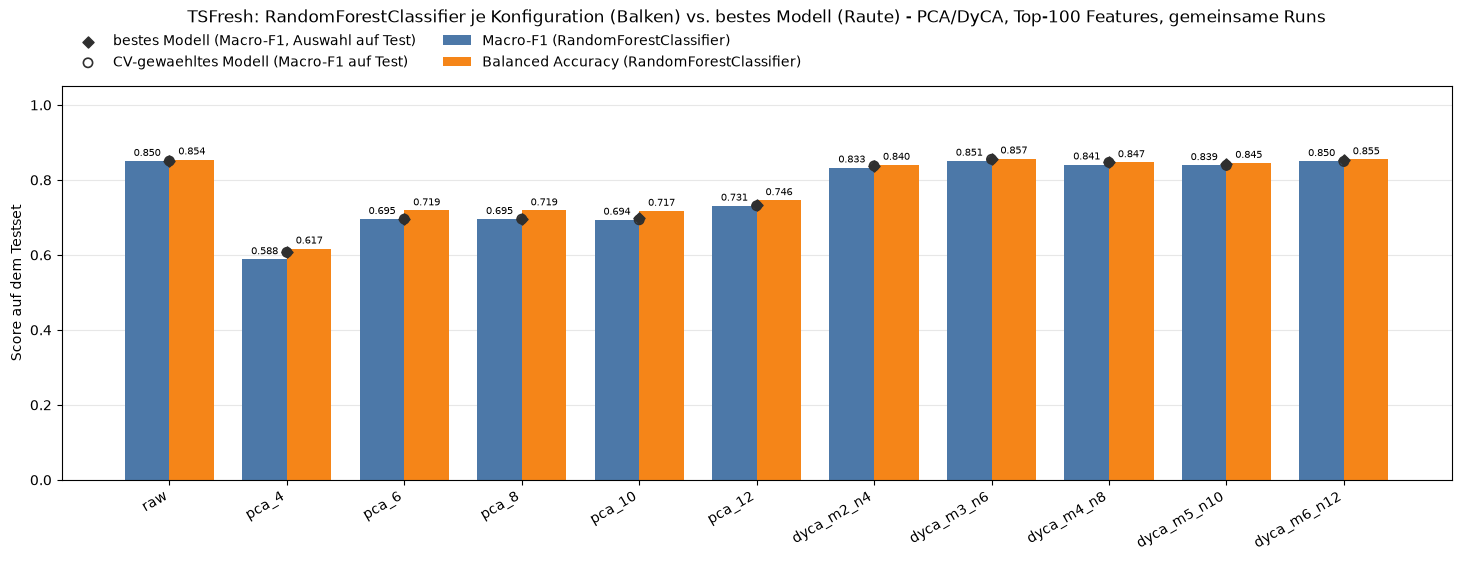

In [8]:
# ============================================================
# Plot: Hauptvergleich (RandomForest) + bestes Modell als Marker
# ============================================================
_ = pipe.plot_comparison(cmp)

## Confusion-Matrizen je Konfiguration

Dieselbe Auswertung wie am Ende von `LazyClassifier_PCA_DyCA.ipynb`, hier über
alle 11 Konfigurationen: **ein fester Modelltyp** — RandomForest, also der
Hauptvergleich von oben — wird pro Konfiguration auf dem **gesamten**
Trainingssatz gefittet und **einmal** auf dem echten Testset ausgewertet. Die
Unterschiede zwischen den Matrizen liegen damit allein an den Features.

**Warum neu gefittet wird.** Phase C berechnet die Vorhersagen zwar schon
(`predictions=True`), überschreibt `preds` aber je Konfiguration und hebt nichts
davon auf. Ein einzelner RF-Fit je Konfiguration auf `top_k = 100` Features
kostet Sekunden bis rund eine Minute — deutlich billiger, als Phase C mit ~25
Modellen zu wiederholen. Die Zelle gleicht am Ende gegen `tsfresh_summary.csv`
ab, ob sie die dortige RandomForest-Zeile reproduziert.

**Datenbasis identisch zu Phase C:** gemeinsame Runs
(`restrict_to_common_runs`), dieselbe NaN/inf-Behandlung, `StandardScaler` +
RandomForest wie lazypredict intern. Die gemeinsamen Runs werden hier neu
bestimmt — die Zelle läuft also auch ohne vorher gelaufenes Phase C, solange
`pipe.train_top`/`pipe.test_top` aus Phase A/B im Kernel liegen.

**Darstellung.** Die Matrizen sind **zeilenweise normiert** (Zeilensumme = 1):
Zelle (i, j) ist der Anteil der wahren Klasse *i*, der als *j* vorhergesagt
wurde, die Diagonale also der Recall. Alle Panels teilen sich die Skala 0…1 und
sind dadurch direkt vergleichbar. Die absoluten Zählwerte stehen als
21×21-DataFrame in `cm.counts[name]`.

Die Vorhersagen werden als `tsfresh_cm_predictions.csv` im Cache abgelegt: nach
einem Kernel-Neustart laufen die Plotzellen darunter ohne Phase A/B/C. `refit
= True` erzwingt die Neuberechnung (nötig, wenn oben etwas geändert wurde).

In [9]:
# ============================================================
# Confusion-Matrizen: RandomForest je Konfiguration
# ============================================================
# refit=False nutzt den Vorhersage-Cache im Cache-Ordner; nach einem
# Kernel-Neustart laufen die Plotzellen darunter damit ganz ohne
# Phase A/B/C. refit=True fittet neu - noetig, wenn ueber estimator=...
# ein anderes Modell verglichen werden soll.
cm = pipe.confusion(refit=False)

Vorhersagen aus tsfresh_cache\tsfresh_cm_predictions.csv geladen (11 Konfigurationen, 109956 Zeilen). refit=True erzwingt Neuberechnung.
Abgleich mit Phase C: groesste Macro-F1-Abweichung 0.0000 (raw)

11 Matrizen berechnet. Absolute Zaehlwerte stehen in .counts, z.B. cm.counts['raw'].


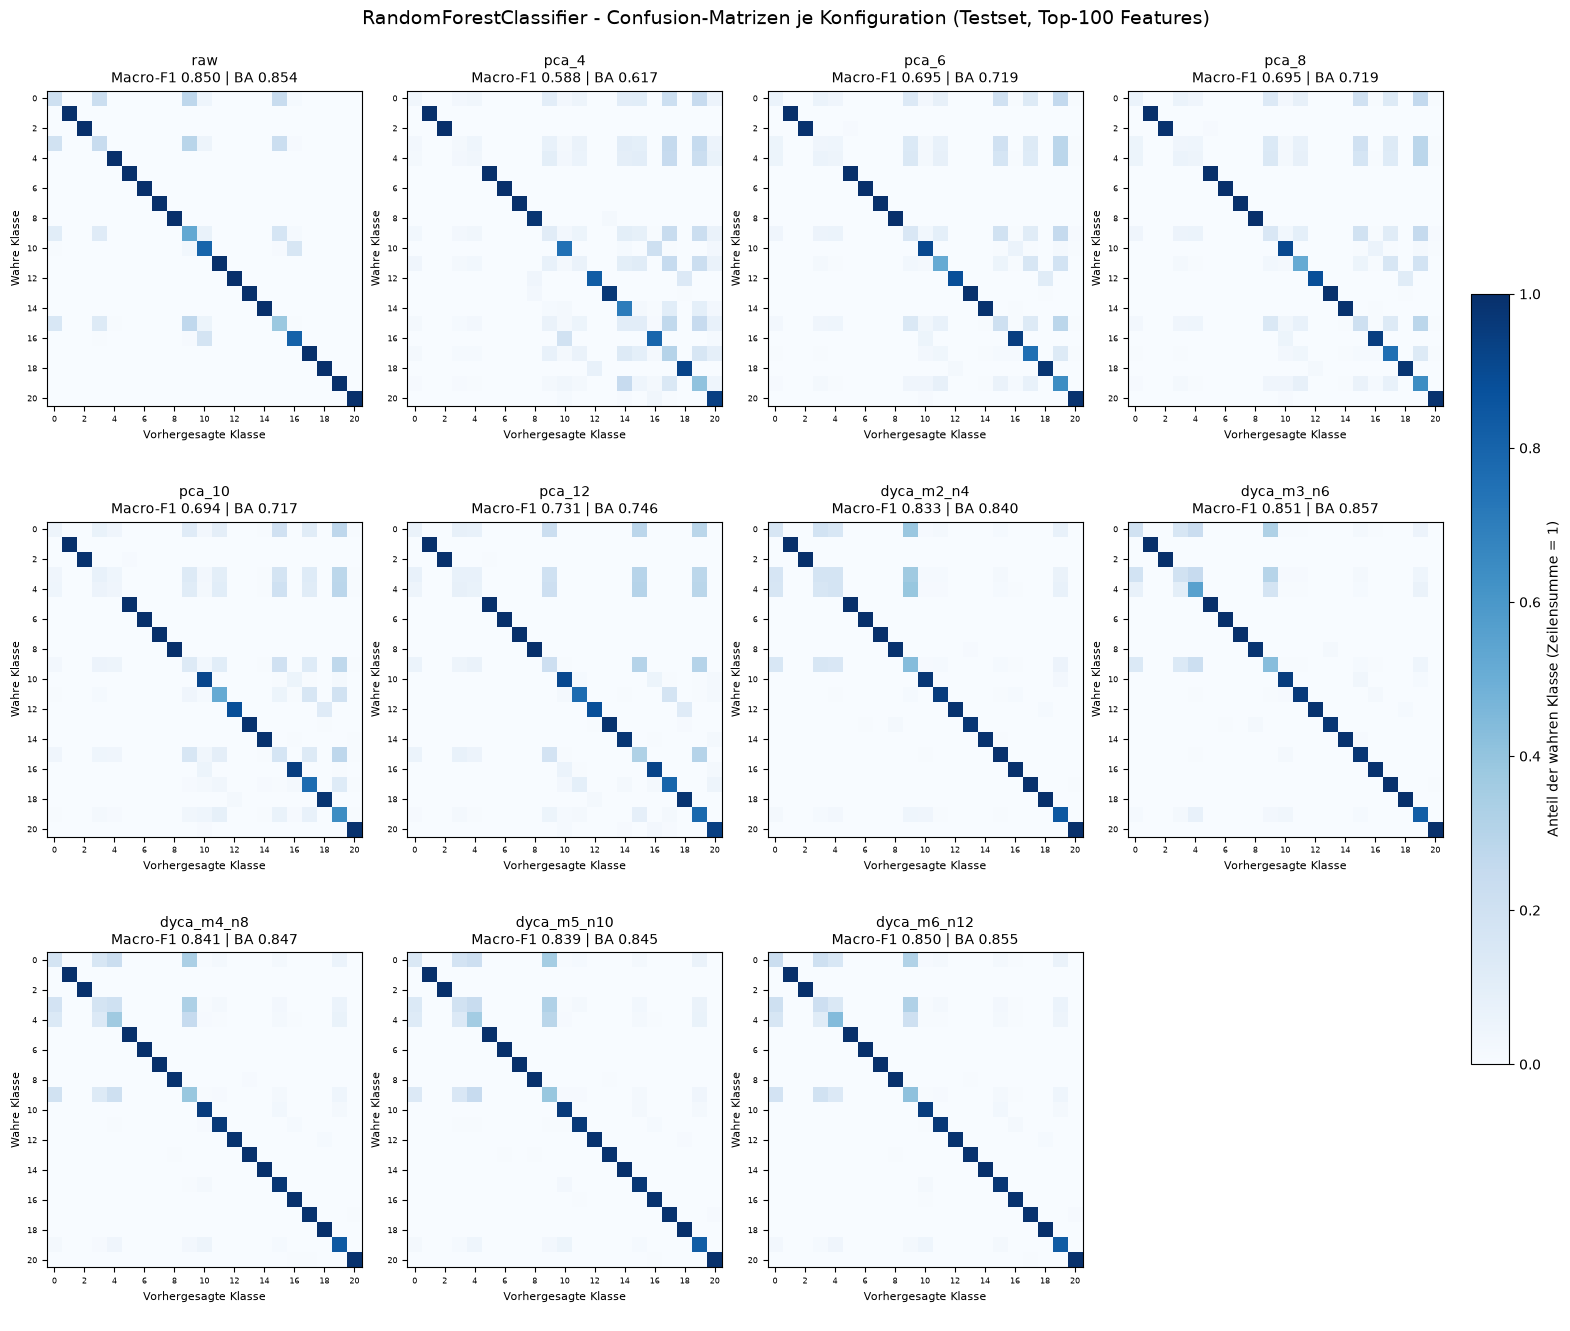

In [10]:
# ============================================================
# Plot: alle Confusion-Matrizen im Raster
# ============================================================
_ = pipe.plot_confusions(cm, ncols=4)

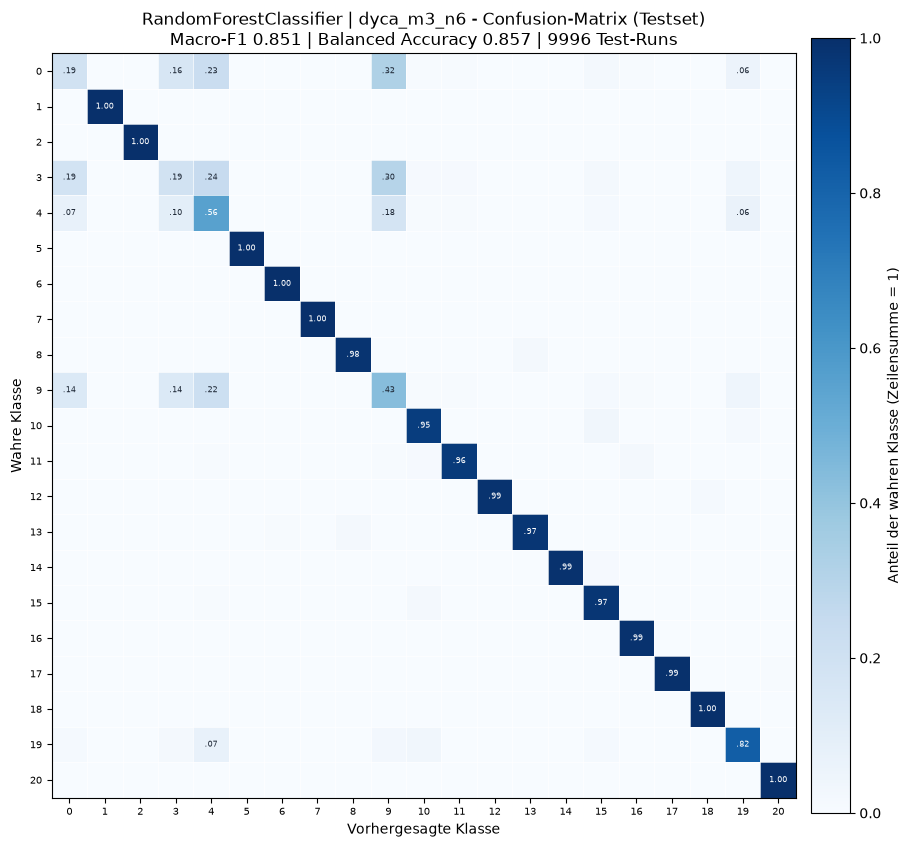

=== dyca_m3_n6: Bericht je Klasse ===
              precision    recall  f1-score   support

           0      0.313     0.190     0.236       479
           1      1.000     1.000     1.000       481
           2      0.998     1.000     0.999       490
           3      0.307     0.189     0.234       477
           4      0.418     0.556     0.478       480
           5      1.000     1.000     1.000       475
           6      0.993     1.000     0.996       408
           7      1.000     1.000     1.000       478
           8      0.982     0.982     0.982       489
           9      0.343     0.431     0.382       485
          10      0.912     0.949     0.930       472
          11      0.972     0.960     0.966       477
          12      1.000     0.987     0.994       476
          13      0.981     0.975     0.978       476
          14      1.000     0.992     0.996       485
          15      0.889     0.975     0.930       476
          16      0.969     0.992     0.980

,pred_0,pred_1,pred_2,pred_3,pred_4,pred_5,pred_6,pred_7,pred_8,pred_9,...,pred_11,pred_12,pred_13,pred_14,pred_15,pred_16,pred_17,pred_18,pred_19,pred_20
true_0,91,0,1,78,110,0,0,0,0,155,...,3,0,0,0,9,2,0,0,28,0
true_1,0,481,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
true_2,0,0,490,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
true_3,89,0,0,90,116,0,0,0,0,143,...,4,0,0,0,8,1,0,0,21,0
true_4,36,0,0,47,267,0,0,0,0,86,...,2,0,0,0,7,1,0,0,31,0
true_5,0,0,0,0,0,475,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
true_6,0,0,0,0,0,0,408,0,0,0,...,0,0,0,0,0,0,0,0,0,0
true_7,0,0,0,0,0,0,0,478,0,0,...,0,0,0,0,0,0,0,0,0,0
true_8,0,0,0,0,0,0,0,0,480,0,...,0,0,9,0,0,0,0,0,0,0
true_9,68,0,0,68,105,0,0,0,0,209,...,2,0,0,0,7,2,0,0,21,0


In [11]:
# ============================================================
# Detail: eine Konfiguration gross + groesste Verwechslungen
# ============================================================
# focus=None waehlt die beste Konfiguration nach Macro-F1; sonst z.B.
# focus="raw". annot_min ist die Schwelle, ab der eine Zelle beschriftet
# wird, top_n die Laenge der Verwechslungsliste.
_, focus = plot_confusion_detail(cm, focus=None, annot_min=0.05, top_n=8)

cm.counts[focus]

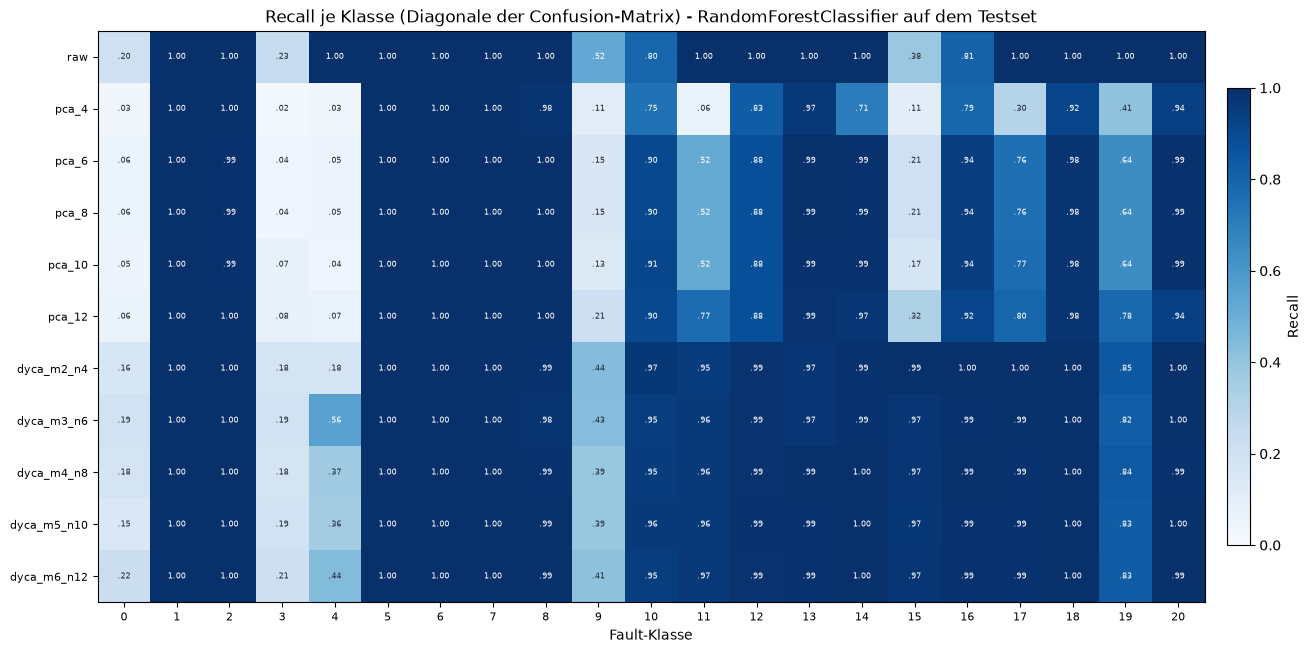

Schwierigste Klassen (mittlerer Recall ueber alle Konfigurationen):
faultNumber
0     0.124
3     0.130
4     0.285
9     0.303
15    0.571


faultNumber,0,1,2,3,4,5,6,7,8,9,...,11,12,13,14,15,16,17,18,19,20
Konfiguration,,,,,,,,,,,,,,,,,,,,,
raw,0.205,1.000,1.000,0.235,1.000,1.000,1.0,1.0,1.000,0.524,...,1.000,0.998,1.000,1.000,0.380,0.805,1.000,1.000,1.000,1.000
pca_4,0.033,0.998,1.000,0.017,0.031,1.000,1.0,1.0,0.980,0.111,...,0.065,0.826,0.968,0.705,0.105,0.792,0.304,0.921,0.408,0.938
pca_6,0.061,1.000,0.992,0.042,0.048,0.998,1.0,1.0,0.998,0.148,...,0.518,0.882,0.994,0.990,0.208,0.943,0.757,0.979,0.641,0.990
pca_8,0.061,1.000,0.992,0.042,0.048,0.998,1.0,1.0,0.998,0.148,...,0.518,0.882,0.994,0.990,0.208,0.943,0.757,0.979,0.641,0.990
pca_10,0.050,1.000,0.992,0.073,0.042,0.998,1.0,1.0,0.998,0.132,...,0.516,0.880,0.992,0.990,0.168,0.943,0.769,0.979,0.643,0.990
pca_12,0.063,1.000,0.996,0.075,0.069,1.000,1.0,1.0,1.000,0.212,...,0.767,0.880,0.987,0.973,0.321,0.918,0.797,0.981,0.779,0.938
dyca_m2_n4,0.159,1.000,1.000,0.176,0.177,1.000,1.0,1.0,0.990,0.437,...,0.952,0.985,0.975,0.992,0.994,0.996,0.996,0.998,0.847,0.998
dyca_m3_n6,0.190,1.000,1.000,0.189,0.556,1.000,1.0,1.0,0.982,0.431,...,0.960,0.987,0.975,0.992,0.975,0.992,0.994,1.000,0.824,1.000
dyca_m4_n8,0.175,1.000,0.996,0.178,0.369,1.000,1.0,1.0,0.992,0.390,...,0.964,0.985,0.994,1.000,0.975,0.994,0.992,0.998,0.842,0.992


In [12]:
# ============================================================
# Recall je Fault-Klasse und Konfiguration
# ============================================================
recall_tab = plot_recall(cm)

recall_tab.round(3)

## Wo weitergemacht werden kann

- **Feature-Namen ansehen:** `pipe.top_names["pca_8"]` zeigt, *welche* TSFresh-Features
  eine Konfiguration ausgewählt hat — oft aufschlussreicher als der Score. Die
  vollständige Rangtabelle liefert `rank_features` (dort auch `p_min`).
- **`top_k` variieren:** die Auswahl ist gecacht, ein anderer Wert erzwingt aber eine
  neue Selektion. Die teure Extraktion in `cache_dir` bleibt gültig.
- **CV wieder abschalten:** `lc_cv_folds = 0` in der Konfigurationszelle nimmt
  die 5-fache Train-CV aus Phase C heraus und spart grob das 2- bis 4-Fache der
  Phase-C-Zeit; die Modellauswahl fällt dann auf das Test-Maximum zurück. Die
  teuren Phasen A/B sind nicht betroffen und bleiben gecacht.
- **Konfigurationen kombinieren:** `pd.concat([pipe.train_top["raw"], pipe.train_top["dyca_m4_n8"]], axis=1)`
  ergibt einen gemeinsamen Feature-Satz — analog zum PCA+DyCA-Fall im
  Eigenwert-Notebook.
- **Skalierung umstellen:** `scaling_mode` in der Konfigurationszelle
  (`"global_mean"` ↔ `"scaler"`) — dann in den Eigenwert-Notebooks gleichziehen
  (dort ist es jeweils die Zeile `X_scaled = ...`). Der Cache-Ordner
  bekommt den Modus automatisch angehängt, alte Ergebnisse werden also nicht
  überschrieben.
- **Confusion-Matrizen:** das `cm`-Objekt aus der Zelle oben hält
  `cm.results` (Matrizen + Scores), `cm.counts` (absolute Zählwerte je
  Konfiguration) und `cm.recall_table()` (Recall je Klasse) bereit. Für
  ein anderes Modell `pipe.confusion(estimator=..., refit=True)` aufrufen
  — ohne `refit=True` wird der Vorhersage-Cache `tsfresh_cm_predictions.csv`
  weiterverwendet.

- **Eigenes Verfahren ergänzen:** ein neuer `Projector` wird über
  `tep.tsfresh.register("mein_verfahren", Projector(...))` eingetragen und
  ist danach als Spec `("mein_verfahren", …)` in `CFG.configs` nutzbar —
  an der Pipeline selbst muss dafür nichts geändert werden. Vorbild sind
  die sieben Einträge in `tep/tsfresh/projections.py`; ein `Projector`
  braucht nur `name`, `channels` und `apply`.